In [1]:
%load_ext autoreload
%autoreload 2

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from sys import path
path.append('../../fourier/')
path.append('../../signals/')
path.append('../../wavelet//')

import stft
import signals as sg
import wavelet_funcs as wf

In [2]:
from scipy.signal import periodogram

----

In [73]:
t_inj1 = 520 # dummy injection times
t_inj2 = 402

In [122]:
x1 = xr.open_dataset('../../data/20241015a_vehicle_vessel1_REG_INTERP_TimeSeries.nc').tlsc_xymean
x2 = xr.open_dataset('../../data/20241023a_vehicle_vessel0_TimeSeries.nc').tlsc_xymean

In [123]:
x1 = x1.assign_coords(t=x1.t-t_inj1)
x2 = x2.assign_coords(t=x2.t-t_inj2)

In [124]:
window_size_s = 150 # s, min injection time over all data
fs = 2 # Hz, same for all data
window_size = int(window_size_s*fs)

In [125]:
x1_trim, t1_trim, idx_inj1 = stft.trim_to_windows_around_injection(x1, x1.t, 0, window_size_s)
x2_trim, t2_trim, idx_inj2 = stft.trim_to_windows_around_injection(x2, x2.t, 0, window_size_s)

In [126]:
p1 = stft.windowed_periodogram(x1_trim, fs, window_size=window_size, time_values=t1_trim)
p2 = stft.windowed_periodogram(x2_trim, fs, window_size=window_size, time_values=t2_trim)

(-629.7269266367, 1784.2654593707)

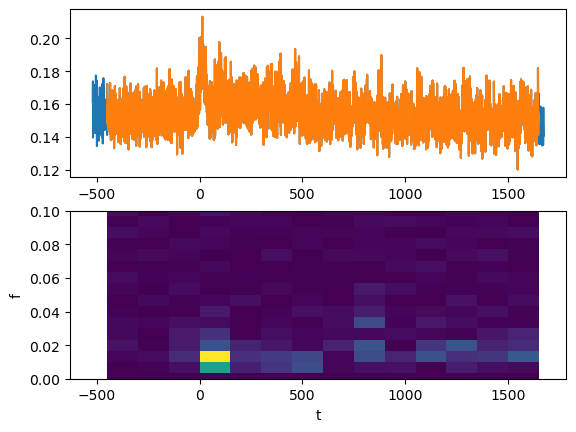

In [127]:
f, (ax,ax1) = plt.subplots(2,1)
ax.plot(x1.t, x1)
ax.plot(t1_trim, x1_trim)
p1.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)
ax1.set_xlim(ax.get_xlim())

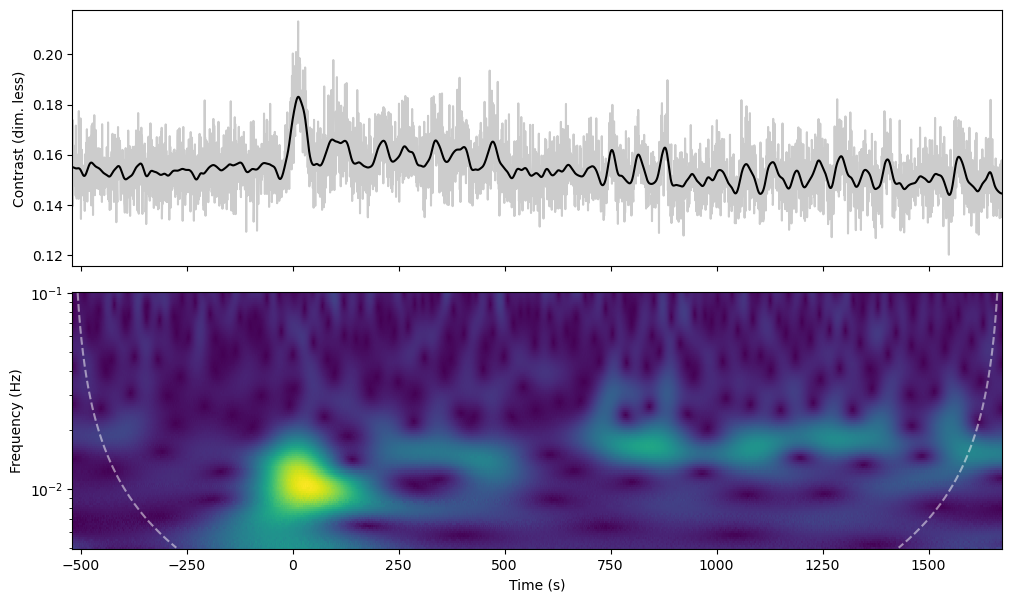

In [148]:
f, (ax,ax1) = wf.plot_timeseries_and_its_cwt(x1, x1.t, f1=0.005, f2=0.1, padding_fraction=0.2, sigma_gb=11)
ax1.set_yscale('log')

(-498.6767503925, 1628.2117582425)

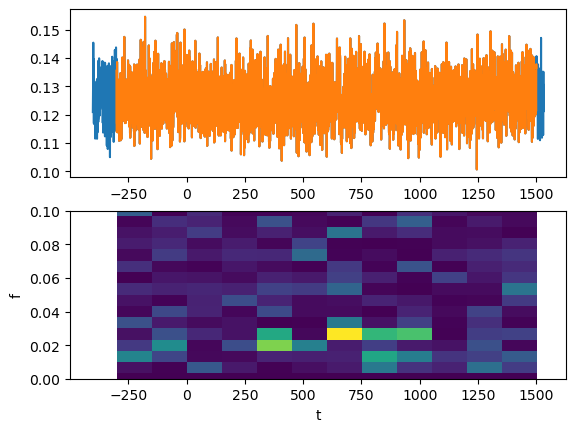

In [128]:
f, (ax,ax1) = plt.subplots(2,1)
ax.plot(x2.t, x2)
ax.plot(t2_trim, x2_trim)
p2.plot.imshow(ax=ax1, add_colorbar=False)
ax1.set_ylim(0,0.1)
ax1.set_xlim(ax.get_xlim())

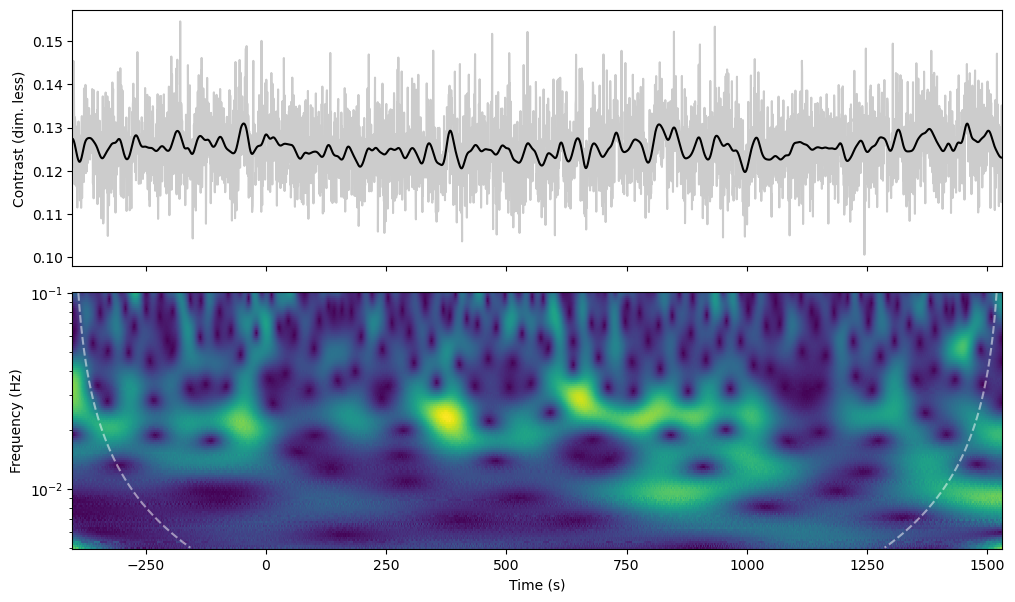

In [149]:
f, (ax,ax1) = wf.plot_timeseries_and_its_cwt(x2, x2.t, f1=0.005, f2=0.1, padding_fraction=0.2, sigma_gb=11)
ax1.set_yscale('log')

In [129]:
p1_ = p1.assign_coords(t=p1.t.round(0))
p2_ = p2.assign_coords(t=p2.t.round(0))

In [130]:
p = xr.concat([p1_, p2_], dim='rat')

(0.0, 0.1)

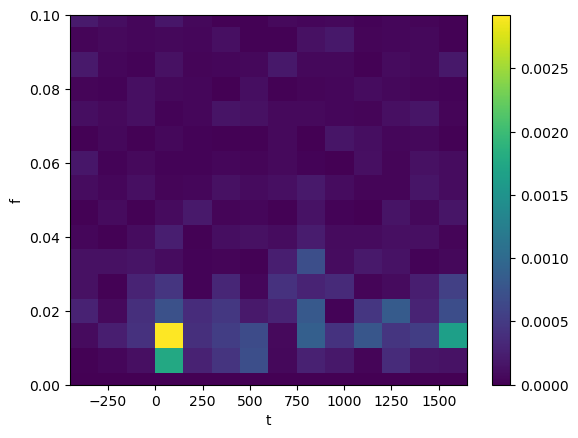

In [131]:
p.mean('rat').plot.imshow()
plt.ylim(0,0.1)

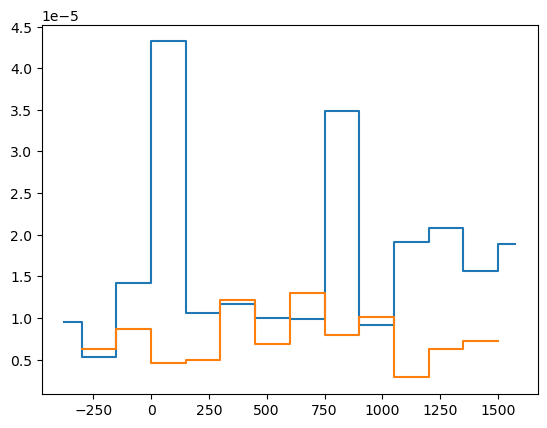

In [141]:
fsel = slice(0.01, 0.1)

for _, pi in p.groupby('rat'):
    plt.step(
        pi.t, pi.sel(f=fsel).integrate('f'),
        where='mid'
    )

<ErrorbarContainer object of 3 artists>

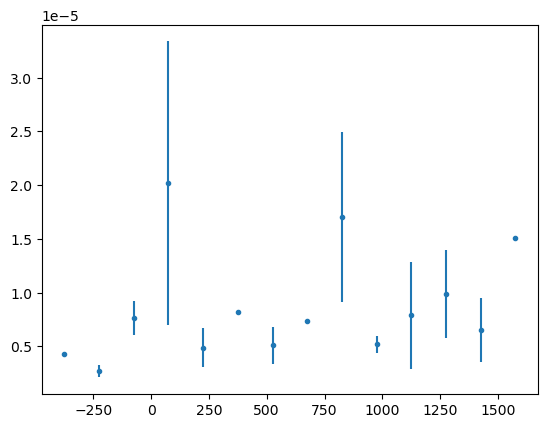

In [133]:
fsel = slice(0.01, 0.05)

plt.errorbar(
    p.t,
    p.sel(f=fsel).integrate('f').mean('rat'),
    p.sel(f=fsel).integrate('f').std('rat') / np.sqrt(2),
    ls='',
    marker='.'
    
)